# **Setup**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (8, 4.5)

from pathlib import Path

data_candidates = [Path("titanic.csv"), Path("content/titanic.csv")]
data_path = next((path for path in data_candidates if path.exists()), None)
if data_path is None:
    raise FileNotFoundError("Couldnot find titanic.csv.")

df = pd.read_csv(data_path)
print(df.shape[0], "Rows")

# For lowercase header
df.columns = df.columns.str.strip().str.lower()
print("\n",df.columns.tolist())

# Survival Rate
print(f"\nSurvival Rate: {df["survived"].mean():.1%}")

1000 Rows

 ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare']

Survival Rate: 44.0%


In [2]:
# Impute age using the median within pclass and sex groups.
df["sex_male"] = (df["sex"] == 'male').astype(int)
print(df[['sex', "sex_male"]].head())

df["age"] = df.groupby(["pclass", "sex"])['age'].transform(lambda x: x.fillna(x.median()))
print("\n",df.head(10))

      sex  sex_male
0  female         0
1    male         1
2    male         1
3    male         1
4    male         1

    survived  pclass     sex   age  sibsp  parch    fare  sex_male
0         1       2  female  17.8      0      0   23.94         0
1         0       3    male  18.5      1      0   29.07         1
2         0       3    male  26.6      1      0   17.63         1
3         0       3    male  34.7      0      2   13.72         1
4         1       1    male  42.0      0      0  128.90         1
5         0       1    male  18.9      0      0  154.86         1
6         0       1    male  49.9      1      0   64.68         1
7         1       3    male  26.0      0      2   11.45         1
8         1       3  female  29.4      0      0    9.88         0
9         0       3    male  19.6      0      0   39.02         1


In [3]:
# Fill missing Fare with median
df["fare"] = df['fare'].fillna(df["fare"].median())

In [4]:
# select required features
features = [
    "pclass", "sex_male", "age",
     "sibsp", "parch", "fare"
]

print("Features in Dataset -->", features)

Features in Dataset --> ['pclass', 'sex_male', 'age', 'sibsp', 'parch', 'fare']


In [5]:
from sklearn.model_selection import train_test_split

X = df[features].astype(float)
y = df["survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training Rows:", len(X_train))
print("Testing Rows:", len(X_test))
print(f"Training Survival Rate: {y_train.mean():.1%}")
print(f"Testing Survival Rate: {y_test.mean():.1%}")

Training Rows: 800
Testing Rows: 200
Training Survival Rate: 44.0%
Testing Survival Rate: 44.0%


# **Part A — Understand the instability you are fixing**
## **TASK 01 — Bootstrap samples by hand**

In [6]:
from sklearn.tree import DecisionTreeClassifier

def bootstrap_sample(X, y,rng):
    idx = rng.integers(0, len(X), size=len(X))
    X_boot = X.iloc[idx]
    y_boot = y.iloc[idx]
    return X_boot, y_boot
    
# Create one bootstrap sample
rng = np.random.default_rng(7)
X_boot, y_boot = bootstrap_sample(X_train, y_train, rng)

print("Original Training Rows:", len(X_train))
print("Bootstrap Rows:", len(X_boot))

Original Training Rows: 800
Bootstrap Rows: 800


In [7]:
# Number of unique rows
unique_rows = X_boot.index.nunique()
print("Unique Original Rows:", unique_rows)

Unique Original Rows: 502


In [8]:
# Number of rows never selected
never_selected = len(X_train) - unique_rows
print("Rows never selected:", never_selected)

Rows never selected: 298


In [9]:
# Example row selected more than once
counts = X_boot.index.value_counts()
duplicate_idx = counts[counts > 1]
print("Example row selected more than once")

if len(duplicate_idx) > 0:
    print(duplicate_idx.head(1))
else:
    print("No duplicate happened in this particular sample.")

Example row selected more than once
57    5
Name: count, dtype: int64


In [10]:
# Repeat bootstrap 100 times
rng = np.random.default_rng(7)

unique_proportions = []

for _ in range(100):
    X_boot, y_boot = bootstrap_sample(X_train, y_train, rng)

    unique_count = X_boot.index.nunique()
    proportion = unique_count / len(X_train)

    unique_proportions.append(proportion)

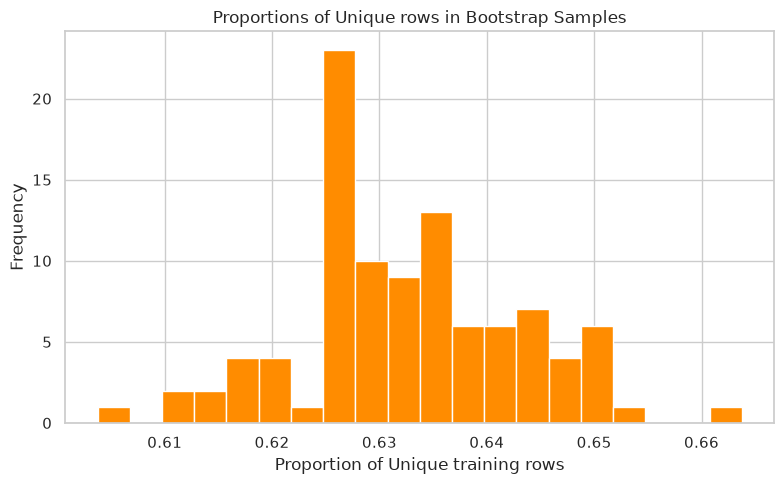

In [11]:
# Plot a histogram
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(unique_proportions, bins=20, color="darkorange", edgecolor="white")
ax.set_title("Proportions of Unique rows in Bootstrap Samples")
ax.set_xlabel("Proportion of Unique training rows")
ax.set_ylabel("Frequency")
plt.tight_layout()
plt.savefig("Bootstrap_sample.png", dpi=300, bbox_inches="tight")
plt.show()

* Duplicates and missing rows are expected because bootstrap sampling is done
with replacement. Each draw is independent, so the same training row can be
selected multiple times. Because the bootstrap sample has a fixed number of
draws, some original rows will not be selected at all. These different samples
provide different views of the same training dataset, which helps ensemble
methods reduce the instability of individual decision trees.


## **TASK 02 — Make five trees disagree**

In [12]:
rng = np.random.default_rng(7)
trees, predictions = [], []
for i in range(5):
    X_boot, y_boot = bootstrap_sample(X_train, y_train, rng)
    tree = DecisionTreeClassifier(max_depth=5, random_state=i).fit(X_boot, y_boot)
    trees.append(tree)
    predictions.append(tree.predict(X_test.iloc[:20])) # Predict first 20 test passengers

predictions = np.array(predictions)

for i in range(20):
    votes = predictions[:, i]
    agree = len(set(votes)) == 1
    print(f"passenger {i} : {votes}   {'(Agree)' if agree else '(Disagree)'}")


# Calculate Disagree percentage
disagree_rate = np.mean([len(set(predictions[:, i])) > 1 for i in range(20)])
print(f"\nThe 5 trees disagree on {disagree_rate:.0%} of these passengers")

passenger 0 : [1 1 1 1 1]   (Agree)
passenger 1 : [0 1 0 0 0]   (Disagree)
passenger 2 : [0 1 1 0 1]   (Disagree)
passenger 3 : [0 0 0 0 0]   (Agree)
passenger 4 : [0 0 1 1 0]   (Disagree)
passenger 5 : [0 0 0 1 1]   (Disagree)
passenger 6 : [0 0 0 0 0]   (Agree)
passenger 7 : [1 1 1 1 1]   (Agree)
passenger 8 : [1 1 1 1 1]   (Agree)
passenger 9 : [1 0 1 1 0]   (Disagree)
passenger 10 : [1 1 1 1 1]   (Agree)
passenger 11 : [1 1 1 1 1]   (Agree)
passenger 12 : [0 0 0 1 0]   (Disagree)
passenger 13 : [0 0 0 0 0]   (Agree)
passenger 14 : [1 1 1 1 1]   (Agree)
passenger 15 : [0 0 0 0 0]   (Agree)
passenger 16 : [1 0 0 1 1]   (Disagree)
passenger 17 : [0 0 0 0 0]   (Agree)
passenger 18 : [1 0 1 0 0]   (Disagree)
passenger 19 : [1 0 1 1 1]   (Disagree)

The 5 trees disagree on 45% of these passengers


In [13]:
# Create dataframe with predictions and voting
X_test_pred = X_test.iloc[:20]
y_test_pred = y_test.iloc[:20]

prediction_data = {}

for i, tree in enumerate(trees, start=1):
    prediction_data[f"tree_{i}"] = tree.predict(X_test_pred)

pred_df = pd.DataFrame(prediction_data, index=X_test_pred.index)

# Count votes for class 1(survival)
pred_df["vote_count"] = pred_df.sum(axis=1)

# majority prediction
# with 5 trees 3 or more votes means class 1
pred_df["forest_majority"] = (pred_df["vote_count"] >= 3).astype(int)

# add true labels
pred_df["true_labels"] = y_test_pred.values

# Display complete dataframe
print("Prediction Dataframe")
print("-" * 21)
print(pred_df)

Prediction Dataframe
---------------------
     tree_1  tree_2  tree_3  tree_4  tree_5  vote_count  forest_majority  \
262       1       1       1       1       1           5                1   
819       0       1       0       0       0           1                0   
997       0       1       1       0       1           3                1   
341       0       0       0       0       0           0                0   
546       0       0       1       1       0           2                0   
521       0       0       0       1       1           2                0   
914       0       0       0       0       0           0                0   
71        1       1       1       1       1           5                1   
247       1       1       1       1       1           5                1   
98        1       0       1       1       0           3                1   
397       1       1       1       1       1           5                1   
527       1       1       1       1       1  

In [14]:
# Identify at least three passengers where the five trees disagree.
pred_df = pd.DataFrame({
    "tree_1": predictions[0],
    "tree_2": predictions[1],
    "tree_3": predictions[2],
    "tree_4": predictions[3],
    "tree_5": predictions[4],
})
trees_col = [
    "tree_1", "tree_2", "tree_3",
    "tree_4", "tree_5"
]

disagree = pred_df[
    pred_df[trees_col].nunique(axis=1) > 1
]

print("Passengers where the 5 trees disagree")
print(disagree.head(3))

Passengers where the 5 trees disagree
   tree_1  tree_2  tree_3  tree_4  tree_5
1       0       1       0       0       0
2       0       1       1       0       1
4       0       0       1       1       0


In [15]:
# Show vote split for 3 selected passengers
for idx, row in disagree.head(3).iterrows():
    survive = int(row[trees_col].sum())
    not_survive = 5 - survive

    print(f"Passenger {idx}  {survive} survived and {not_survive} do not survive")

Passenger 1  1 survived and 4 do not survive
Passenger 2  3 survived and 2 do not survive
Passenger 4  2 survived and 3 do not survive


# **Part B — Build bagging and Random Forests**
## **TASK 03 — Implement a bagged forest manually**

In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, accuracy_score

rng = np.random.default_rng(7)
trees = []

start_time = time.perf_counter()

for i in range(100):
    X_boot, y_boot = bootstrap_sample(X_train, y_train, rng)
    tree = DecisionTreeClassifier(max_depth=5, random_state=42).fit(X_boot, y_boot)
    trees.append(tree)

manual_bagging_time = time.perf_counter() - start_time
# Collect predictions from all 100 trees
tree_predictions = np.array([tree.predict(X_test) for tree in trees])
tree_probabilities = np.array([tree.predict_proba(X_test)[:, 1] for tree in trees])

print("Number of Trees:", len(trees))
print("Training Time:", manual_bagging_time)
print("\nTree Predictions shape:", tree_predictions.shape)
print("Tree Predictions:", tree_predictions)
print("\nTree Probabilities shape:", tree_probabilities.shape)
print("Tree Probabilities:", tree_probabilities)

Number of Trees: 100
Training Time: 0.15476528799626976

Tree Predictions shape: (100, 200)
Tree Predictions: [[1 0 0 ... 1 0 0]
 [1 1 1 ... 1 0 1]
 [1 0 1 ... 1 0 0]
 ...
 [1 0 1 ... 1 0 0]
 [1 0 1 ... 1 0 0]
 [1 0 0 ... 1 0 1]]

Tree Probabilities shape: (100, 200)
Tree Probabilities: [[0.77777778 0.31481481 0.         ... 0.73188406 0.         0.31481481]
 [1.         0.75       1.         ... 0.8        0.         1.        ]
 [0.96923077 0.28787879 1.         ... 0.96923077 0.03125    0.28787879]
 ...
 [0.875      0.15217391 1.         ... 0.875      0.19078947 0.34782609]
 [0.92682927 0.16129032 1.         ... 0.92682927 0.12878788 0.34146341]
 [1.         0.30864198 0.         ... 1.         0.03846154 0.50806452]]


In [44]:
# Majority-vote class prediction
majority_vote = (tree_predictions.mean(axis=0) >=0.5).astype(int)

# Average survival probability
mean_probability = tree_predictions.mean(axis=0)

# Accuracy and ROC-AUC
manual_acc = accuracy_score(y_test, majority_vote)
manual_roc_auc = roc_auc_score(y_test, mean_probability)

print("Forest Result")
print("-" * 14)
print(f"Accuracy: {manual_acc:.4f}")
print(f"ROC-AUC: {manual_roc_auc:.4f}")

Forest Result
--------------
Accuracy: 0.7650
ROC-AUC: 0.8734


In [18]:
# single depth-5 tree trained on the full X_train.
start_time = time.perf_counter()
single_tree = DecisionTreeClassifier(max_depth=5, random_state=i).fit(X_train, y_train)
single_tree_time = time.perf_counter() - start_time
single_prediction = single_tree.predict(X_test)
single_probability = single_tree.predict_proba(X_test)[:, 1]

single_acc = accuracy_score(y_test, single_prediction)
single_roc_auc = roc_auc_score(y_test, single_probability)

print("Single Tree Results")
print("-" * 20)
print(f"Single Tree Accuracy: {single_acc:.4f}") 
print(f"Single Tree ROC-AUC: {single_roc_auc:.4f}")
print(f"Single Tree Training time: {single_tree_time:.4f}")

Single Tree Results
--------------------
Single Tree Accuracy: 0.7500
Single Tree ROC-AUC: 0.8110
Single Tree Training time: 0.0022


In [19]:
# Compare the two models
comparison = pd.DataFrame({
    "Model": ["single depth-5 tree", "Forest (100 Trees)"],
    "Accuracy": [single_acc, manual_acc],
    "ROC-AUC Score":[single_roc_auc, manual_roc_auc]
})

print("Comparison")
print("-" * 11)
print(comparison)

Comparison
-----------
                 Model  Accuracy  ROC-AUC Score
0  single depth-5 tree     0.750       0.811029
1   Forest (100 Trees)     0.765       0.873377


In [20]:
# The 100 tree probabilities for one test passenger with a close vote
# Average probability between 0.4 and 0.6
close_idx = np.where(
    (mean_probability >= 0.4) &
    (mean_probability <= 0.6)
)[0]

if len(close_idx) > 0:
    passenger_idx = close_idx[0]
    print("Passenger selected for histogram:", passenger_idx)
    print("Average survival probaility", mean_probability[passenger_idx])
    
    # Probabilities from all 100 trees for this passenger
    passenger_prob = tree_probabilities[:, passenger_idx]

else:
    print("No passenger found with average probability between 0.4 and 0.6")

Passenger selected for histogram: 24
Average survival probaility 0.43


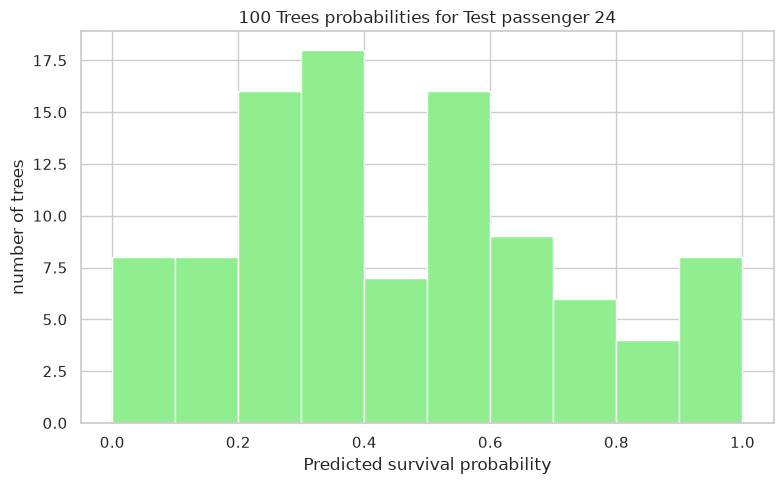

In [21]:
# plot histogram
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(passenger_prob, bins=10, color="lightgreen", edgecolor="white")
ax.set_title(f"100 Trees probabilities for Test passenger {passenger_idx}")
ax.set_xlabel("Predicted survival probability")
ax.set_ylabel("number of trees")
plt.tight_layout()
plt.savefig("close_vote.png", dpi=300, bbox_inches="tight")
plt.show()

## **TASK 04 — Compare a tree, bagging, and a Random Forest**

In [22]:
import time

start_time = time.perf_counter()
rf = RandomForestClassifier(n_estimators=200, random_state=42).fit(X_train, y_train)
rf_time = time.perf_counter() - start_time

rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:, 1]

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_roc_auc = roc_auc_score(y_test, rf_prob)

print(f"Random forest accuracy: {rf_accuracy:.4f}")
print(f"Random forest ROC-AUC: {rf_roc_auc:.4f}")
print(f"Random Forest training Time: {rf_time:.4f}")

Random forest accuracy: 0.7400
Random forest ROC-AUC: 0.8322
Random Forest training Time: 0.1897


In [23]:
# comparison
comparison = pd.DataFrame({
    "Model": ["Single Tree", "Manual Bagging", "Random Forest"],
    "Accuracy": [single_acc, manual_acc, rf_accuracy],
    "ROC-AUC": [single_roc_auc, manual_roc_auc, rf_roc_auc],
    "Training Time": [single_tree_time, manual_bagging_time, rf_time]
})

comparison

,Model,Accuracy,ROC-AUC,Training Time
0,Single Tree,0.750,0.811029,0.002185
1,Manual Bagging,0.765,0.873377,0.154765
2,Random Forest,0.740,0.832234,0.189680


In [24]:
# 25 Bootstrap experiments
results = []
for seed in range (25):
    rng = np.random.default_rng(seed)
    X_boot, y_boot = bootstrap_sample(X_train, y_train, rng)

    # For single tree
    tree = DecisionTreeClassifier(max_depth=5, random_state=seed).fit(X_boot, y_boot)
    tree_prob = tree.predict_proba(X_test)[:, 1]
    tree_auc = roc_auc_score(y_test, tree_prob)


    # Manual bagging
    bag_trees = []
    bag_rng = np.random.default_rng(seed)
    for j in range(100):
        X_bag, y_bag = bootstrap_sample(X_boot, y_boot, bag_rng)
        model = DecisionTreeClassifier(max_depth=5, random_state=seed * 1000 + j).fit(X_bag, y_bag)
        bag_trees.append(model)

        
    bag_prob = np.array([model.predict_proba(X_test)[:, 1]
                            for model in bag_trees])
    bag_mean_prob = bag_prob.mean(axis=0)
    bag_auc = roc_auc_score(y_test, bag_mean_prob)


    # Random Forest
    rf = RandomForestClassifier(n_estimators=200, random_state=seed).fit(X_boot, y_boot)
    rf_prob = rf.predict_proba(X_test)[:, 1]
    rf_auc = roc_auc_score(y_test, rf_prob)

    # Results
    results.append({
        "Seed": seed,
        "Single Tree": tree_auc,
        "Manual Bagging": bag_auc,
        "Random Forest": rf_auc
    })


stability_df = pd.DataFrame(results)
stability_df

,Seed,Single Tree,Manual Bagging,Random Forest
0,0,0.840047,0.865310,0.816000
1,1,0.805195,0.870992,0.844409
2,2,0.831473,0.862317,0.833604
3,3,0.768770,0.860897,0.830103
4,4,0.830763,0.874087,0.814681
5,5,0.836546,0.878145,0.828531
6,6,0.831220,0.880834,0.827719
7,7,0.791345,0.850446,0.802861
8,8,0.807681,0.863738,0.828480
9,9,0.848316,0.883929,0.824320


In [59]:
stability_df.to_csv("Model comparison chart.csv", index=False)

In [25]:
# Mean and Standard Deviation
summary = pd.DataFrame({
    "Mean ROC-AUC": [
        stability_df["Single Tree"].mean(),
        stability_df["Manual Bagging"].mean(),
        stability_df["Random Forest"].mean()
    ],
    "Std ROC-AUC": [
        stability_df["Single Tree"].std(),
        stability_df["Manual Bagging"].std(),
        stability_df["Random Forest"].std()
    ],
    
}, index=["Single Tree", "Manual Bagging", "Random Forest"])

summary

,Mean ROC-AUC,Std ROC-AUC
Single Tree,0.803369,0.033903
Manual Bagging,0.863910,0.013311
Random Forest,0.825548,0.012865


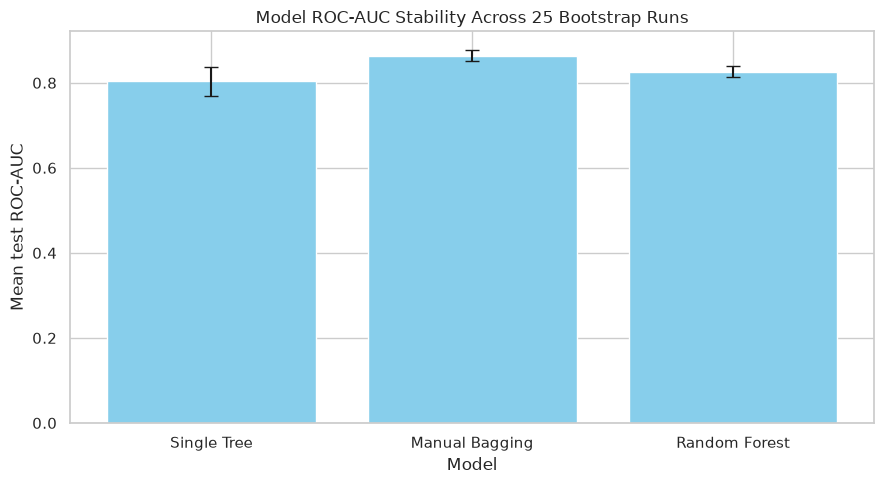

In [26]:
# Bar charts with error bars
fig, ax = plt.subplots(figsize=(9, 5))
models = summary.index
means = summary["Mean ROC-AUC"]
stds = summary["Std ROC-AUC"]
ax.bar(models, means, yerr=stds, color='skyblue', capsize=5)
ax.set_title("Model ROC-AUC Stability Across 25 Bootstrap Runs")
ax.set_xlabel("Model")
ax.set_ylabel("Mean test ROC-AUC")
plt.tight_layout()
plt.show()

# **Conclusion -->**  

The model with the highest average test ROC-AUC was **Manual Bagging Model**, with a
mean ROC-AUC of **0.8639**. The most stable model was **Manual Bagging Model**, because
it had the smallest ROC-AUC standard deviation across the 25 bootstrap runs.

Random Forest differs from plain bagging because Random Forest introduces
additional randomness by considering random subsets of features when creating
tree splits, whereas ordinary bagging mainly creates diversity through
bootstrap samples. A single train/test split does not prove that one model is
universally better because its result can depend on the particular sample
used for training and testing.

# **Part C — Tune efficiently and validate honestly**
## **TASK 05 — Tune the two key Random Forest settings**

In [27]:
# Sweep number of trees
import warnings
warnings.filterwarnings("ignore")

n_estimators_values = [10, 25, 50, 100, 200, 400]
oob_results = []
for n_est in n_estimators_values:
    rf = RandomForestClassifier(n_estimators=n_est, oob_score=True, random_state=42).fit(X_train, y_train)

    oob_results.append({
        "n_estimators": n_est,
        "oob_score": rf.oob_score_
    })

oob_df = pd.DataFrame(oob_results)
oob_df

,n_estimators,oob_score
0,10,0.68375
1,25,0.70250
2,50,0.70875
3,100,0.70250
4,200,0.70125
5,400,0.70625


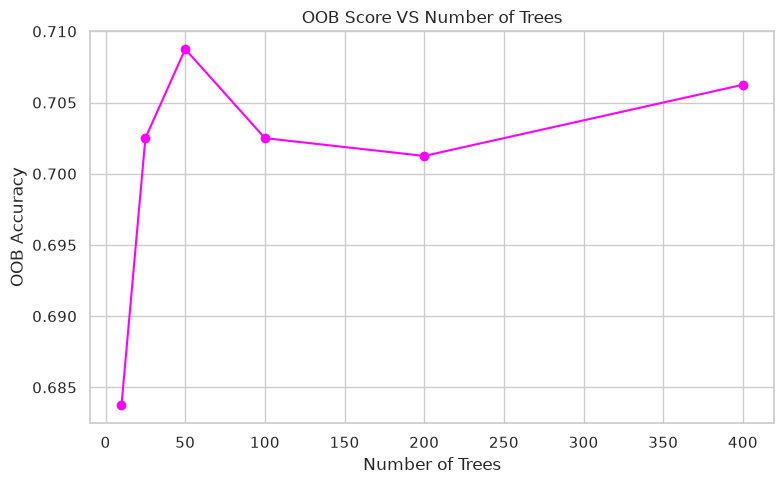

In [28]:
# Plot the oob score
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(oob_df["n_estimators"], oob_df["oob_score"], marker='o', color="magenta")
ax.set_title("OOB Score VS Number of Trees")
ax.set_xlabel("Number of Trees")
ax.set_ylabel("OOB Accuracy")
ax.grid(True)
plt.tight_layout()
plt.show()

In [29]:
# Choose smallest forest within 0.005 of best
best_oob = oob_df["oob_score"].max()
threshold = best_oob - 0.005
eligible = oob_df[oob_df["oob_score"] >= threshold]

choosen_n_estimators = eligible.iloc[0]["n_estimators"]

print("Best OOB:", best_oob)
print("Threshold:", threshold)
print("Choosen smallest n_estimators:", choosen_n_estimators)

Best OOB: 0.70875
Threshold: 0.70375
Choosen smallest n_estimators: 50.0


### Why choose the smallest forest within 0.005?  

The goal is not automatically to choose the largest possible forest. If a
smaller number of trees produces an OOB score within 0.005 of the best score,
the additional trees provide very little performance improvement while
increasing computational cost. This is an example of diminishing returns.

In [30]:
# Tune Max features
max_features = ["sqrt", "log2", 0.5, 1.0]
mf_results = []
for mf in max_features:
    rf = RandomForestClassifier(n_estimators=int(choosen_n_estimators), 
                               max_features=mf, oob_score=True, 
                               random_state=42).fit(X_train, y_train)

    mf_results.append({
        "n_estimators": int(choosen_n_estimators),
        "Max_features": mf,
        "oob_score": rf.oob_score_
    })

tuning_df = pd.DataFrame(mf_results)
tuning_df

,n_estimators,Max_features,oob_score
0,50,sqrt,0.70875
1,50,log2,0.70875
2,50,0.5,0.70375
3,50,1.0,0.68250


In [31]:
# final model using OOB score
best_row = tuning_df.loc[tuning_df["oob_score"].idxmax()]
best_mf = best_row["Max_features"]

print("Selected n_estimators:", int(choosen_n_estimators))
print("Selected Max Features:", best_mf)
print("Best OOB Score:", best_row["oob_score"])

Selected n_estimators: 50
Selected Max Features: sqrt
Best OOB Score: 0.70875


In [32]:
# Train final model
final_rf = RandomForestClassifier(
    n_estimators=int(choosen_n_estimators),
    max_features=best_mf,
    oob_score=True,
    random_state=42
).fit(X_train, y_train)

# FINAL test evaluation — once
final_test_pred = final_rf.predict(X_test)
final_test_prob = final_rf.predict_proba(X_test)[:, 1]

final_test_acc = accuracy_score(y_test, final_test_pred)
final_test_roc_auc = roc_auc_score(y_test, final_test_prob)

final_oob_score = final_rf.oob_score_

print("Final Test Accuracy:", round(final_test_acc, 4))
print("Final Test ROC-AUC:", round(final_test_roc_auc, 4))
print("Final OOB Score:", round(final_oob_score, 4))

Final Test Accuracy: 0.73
Final Test ROC-AUC: 0.8315
Final OOB Score: 0.7087


## **TASK 06 — Inspect OOB predictions and uncertainty**

In [33]:
oob_prob = final_rf.oob_decision_function_[:, 1]

print("Number of OOB probabilities:", len(oob_prob))
print('\n',oob_prob[:10])

Number of OOB probabilities: 800

 [0.         0.15384615 0.70833333 0.2        0.375      0.36363636
 0.625      0.         1.         1.        ]


In [57]:
# Find probabilities closest to 0.5
distance_from_half = np.abs(oob_prob - 0.5)
closest_idx = np.argsort(distance_from_half)[:10]

# Create table
oob_table = X_train.iloc[closest_idx].copy()
oob_table['true_label'] = y_train.iloc[closest_idx].values

oob_table["oob_probabilities"] = (oob_prob[closest_idx])

oob_table["Distance_from_0.5"] = (distance_from_half[closest_idx])
oob_table

,pclass,sex_male,age,sibsp,parch,fare,true_label,oob_probabilities,Distance_from_0.5
554,3.0,0.0,17.5,0.0,0.0,6.46,0,0.5,0.0
907,2.0,1.0,36.1,1.0,0.0,68.44,0,0.5,0.0
708,2.0,1.0,35.6,0.0,0.0,13.17,0,0.5,0.0
94,3.0,0.0,27.2,1.0,0.0,9.08,1,0.5,0.0
912,3.0,1.0,41.4,0.0,0.0,7.07,0,0.5,0.0
614,3.0,0.0,18.8,0.0,0.0,6.55,0,0.5,0.0
952,1.0,1.0,15.1,0.0,0.0,101.53,0,0.5,0.0
631,3.0,0.0,48.2,1.0,0.0,22.72,1,0.5,0.0
334,1.0,1.0,18.8,0.0,0.0,93.27,0,0.5,0.0
223,2.0,1.0,11.9,1.0,0.0,24.10,1,0.5,0.0


In [58]:
oob_table.to_csv("OOB_Score.csv", index=False)

An OOB probability near 0.5 indicates an uncertain prediction because the
forest does not strongly favor either survival class. A probability close to
1 indicates strong support for survival, while a probability close to 0
indicates strong support for non-survival.

In [35]:
# Compare OOB and test accuracy
print("OOB Accuracy:", round(final_oob_score, 4))
print("Test Accuracy:", round(final_test_acc, 4))

difference = abs(final_oob_score - final_test_acc)

print("Absolute Difference", round(difference, 4))

OOB Accuracy: 0.7087
Test Accuracy: 0.73
Absolute Difference 0.0212


# **Part D — Interpret the model responsibly**
## **TASK 07 — Catch a misleading feature-importance result**

In [36]:
# add random noise
rng = np.random.default_rng(2026)

X_train_noise = X_train.copy()
X_test_noise = X_test.copy()

X_train_noise["random_noise"] = rng.normal(size=len(X_train_noise))
X_test_noise["random_noise"] = rng.normal(size=len(X_test_noise))

# Train noisy Random Forest
noise_rf = RandomForestClassifier(n_estimators=300, random_state=42).fit(X_train_noise, y_train)

# Impurity Importance
impurity_importance = pd.Series(
    noise_rf.feature_importances_, index=X_train_noise.columns
)

impurity_df = impurity_importance.sort_values(ascending=False)

impurity_df

fare            0.239975
age             0.212569
random_noise    0.205187
sex_male        0.201685
pclass          0.067796
sibsp           0.041280
parch           0.031508
dtype: float64

In [38]:
# Permutation importance
from sklearn.inspection import permutation_importance
perm_result = permutation_importance(
    noise_rf, X_test_noise, y_test, n_repeats=30, random_state=42, scoring="roc_auc"
)

# Create Dataframe
permutation_imp = pd.Series(
    perm_result.importances_mean, index=X_test_noise.columns
).sort_values(ascending=False)

permutation_imp

sex_male        0.247200
pclass          0.051023
fare            0.028374
random_noise    0.006326
parch          -0.002980
age            -0.004070
sibsp          -0.011759
dtype: float64

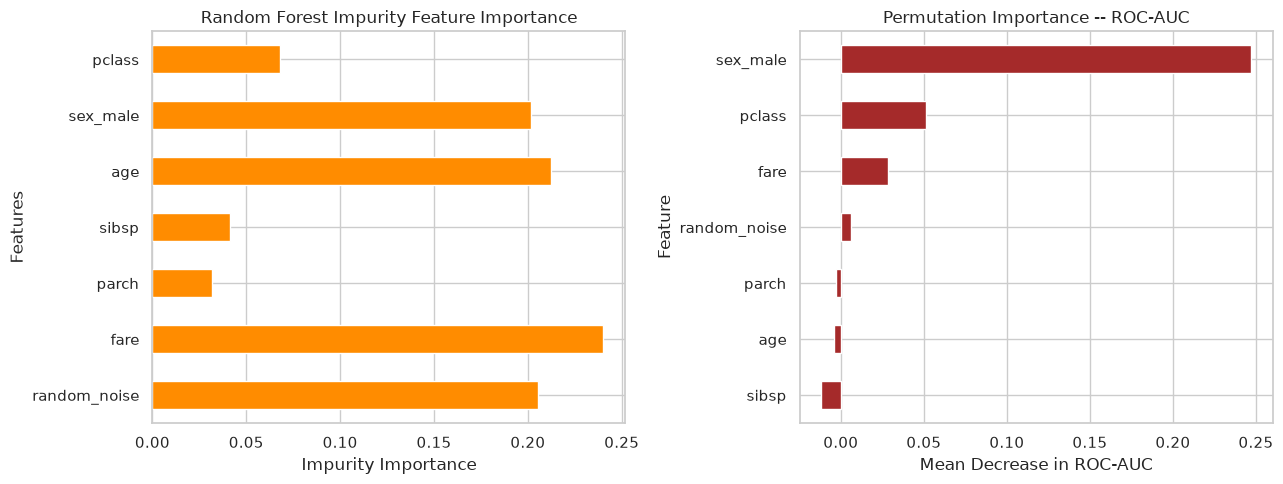

In [52]:
# plot impurity importance
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
impurity_importance.plot(kind="barh", color="darkorange", ax=ax[0])
ax[0].invert_yaxis()
ax[0].set_title("Random Forest Impurity Feature Importance")
ax[0].set_xlabel("Impurity Importance")
ax[0].set_ylabel("Features")

# Plot permutation importance
permutation_imp.plot(kind="barh", color="brown", ax=ax[1])
ax[1].invert_yaxis()
ax[1].set_title("Permutation Importance -- ROC-AUC")
ax[1].set_xlabel("Mean Decrease in ROC-AUC")
ax[1].set_ylabel("Feature")


plt.tight_layout()
plt.savefig("Impurity vs Permutation Important.png", dpi=300, bbox_inches="tight")
plt.show()

In [40]:
# Compare random noise
noise_impurity = impurity_df["random_noise"]
noise_permutation = permutation_imp["random_noise"]

impurity_rank = (impurity_df.index.get_loc("random_noise") + 1)
permutation_rank = (permutation_imp.index.get_loc("random_noise") + 1)

print("Random Noise impurity importance:")
print(round(noise_impurity, 4))
print("\nRandom Noise permutation importance:")
print(round(noise_permutation, 4))
print("\nRandom Noise impurity Rank:")
print(impurity_rank)
print("\nRandom Noise permutation Rank:")
print(permutation_rank)

Random Noise impurity importance:
0.2052

Random Noise permutation importance:
0.0063

Random Noise impurity Rank:
3

Random Noise permutation Rank:
4


# **TASK 08 — Explain two model relationships with PDPs**

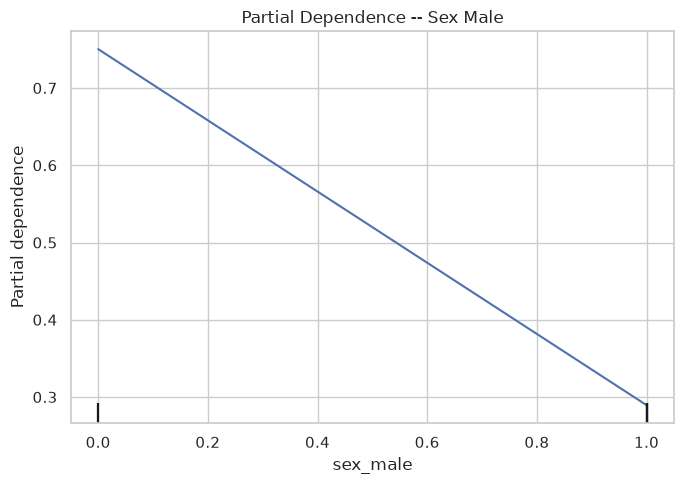

In [48]:
from sklearn.inspection import PartialDependenceDisplay
# PDP For sex_male
fig, ax = plt.subplots(figsize=(7, 5))
PartialDependenceDisplay.from_estimator(final_rf, X_train, ["sex_male"], ax=ax)
ax.set_title("Partial Dependence -- Sex Male")
plt.tight_layout()
plt.savefig("PDP_First.png", dpi=300, bbox_inches="tight")
plt.show()

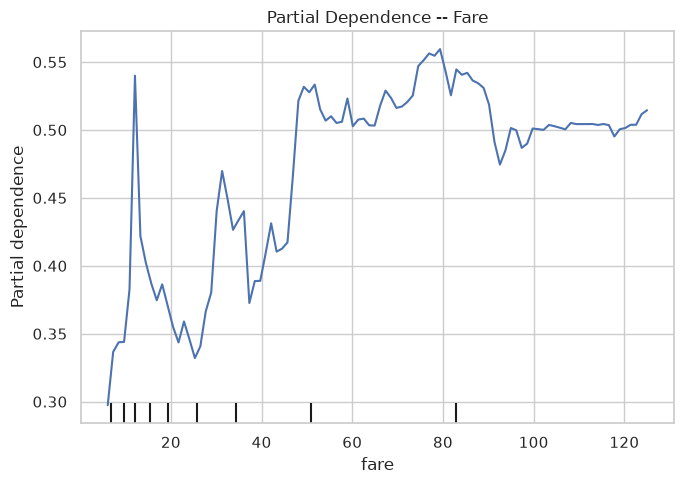

In [45]:
# PDP for Fare
fig, ax = plt.subplots(figsize=(7, 5))
PartialDependenceDisplay.from_estimator(final_rf, X_train, ["fare"], ax=ax)
ax.set_title("Partial Dependence -- Fare")
plt.tight_layout()
plt.savefig("PDP_second.png", dpi=300, bbox_inches="tight")
plt.show()

# What I learned?  

* Bootstrap sampling creates different training datasets by sampling rows with replacement, so some rows can appear multiple times and others can be left out.
* A single decision tree can be unstable because small changes in its training data can produce different predictions.
* Bagging reduces this instability by combining predictions from many trees, while Random Forest adds another source of diversity by using random feature subsets.
* OOB scoring is useful because it gives an internal validation estimate without repeatedly using the held-out test set for model selection.
* Feature importance and PDPs help explain what patterns the model has learned, but they do not prove that an important feature causes the target outcome.